In [14]:
import os
import glob
import numpy as np
import pandas as pd
import torch

In [15]:
LABEL_TO_INT_10 = {str(i): i for i in range(10)}


# Kia CAN IDs you used in your existing pipeline
kia_id = ['0018', '0220', '0316', '043F', '0440', '0510']


BYTE_COLS = ["One","Two","Three","Four","Five","Six","Seven","Eight"]

In [18]:
# -----------------------------
# Step 1) Load CSV folders with labels + file_id
# -----------------------------

def load_csv_folder_with_label(path: str, lbl: str, group: str) -> pd.DataFrame:
    """Load each CSV in 'path' and stamp:
      - Label = lbl ('0'..'9')
      - group (AggKia / ConAttKia / SitAttKia)
      - file_id unique per CSV file (prevents window crossing)
    """
    csv_files = sorted(glob.glob(os.path.join(path, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {path}")

    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        df["Label"] = str(lbl)
        df["group"] = group
        df["file_id"] = f"{group}/lbl{lbl}/{os.path.basename(f)}"
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

# -----------------------------
# Step 2) Parsing helpers
# -----------------------------

def _parse_hex(x) -> int:
    """Parse hex tokens like '0316', '7F', 'ff', '0x7f' into int."""
    if pd.isna(x):
        return 0
    s = str(x).strip()
    if s == "":
        return 0
    s = s.lower()
    if s.startswith("0x"):
        s = s[2:]
    try:
        return int(s, 16)
    except ValueError:
        return int(float(s))


def _normalize_can_id_to_hex4(v) -> str:
    """Normalize df CAN_ID cell to 4-digit lowercase hex string (e.g., '0316')."""
    if pd.isna(v):
        return ""
    s = str(v).strip().lower()
    if s.startswith("0x"):
        s = s[2:]
    # if already hex-like
    try:
        int(s, 16)
        return s.zfill(4)
    except ValueError:
        # decimal fallback
        try:
            return format(int(float(s)), "x").zfill(4)
        except Exception:
            return ""


def filter_ids(df: pd.DataFrame, ids, can_id_col="CAN_ID") -> pd.DataFrame:
    """Keep only selected CAN IDs (ids: list like ['0316', ...])."""
    ids_set = {i.lower().replace("0x", "").zfill(4) for i in ids}
    tmp = df.copy()
    tmp["_nid"] = tmp[can_id_col].map(_normalize_can_id_to_hex4)
    tmp = tmp[tmp["_nid"].isin(ids_set)].drop(columns=["_nid"])
    return tmp

# -----------------------------
# Step 3) LiPar tensorization (per CSV file)
# -----------------------------

def lipar_preprocess_one_file(
    df: pd.DataFrame,
    stride: int = 27,                 # 27 = non-overlapping; 9 or 1 are also possible
    time_col: str = "Time_Offset",
    label_col: str = "Label",
    can_id_col: str = "CAN_ID",
    byte_cols=BYTE_COLS,
    id_scale: float | None = None,    # None -> auto max per file
    normalize_payload: bool = True,
    return_temporal: bool = True,
    label_mode: str = "any_attack",  # any_attack or majority
    allowed_ids=None,
):
    """Convert one file (df) into LiPar samples:
      - per message vector: [CAN_ID, b0..b7] (9 dims)
      - 27 messages -> 3×9×9 tensor
      - temporal -> 27×9 tensor (order preserved)

    Label rule (LiPar-style):
      - if all 27 labels are '0' => y=0
      - else choose attack label within window
    """

    # optional ID filtering (to match your kia_id usage)
    if allowed_ids is not None:
        df = filter_ids(df, allowed_ids, can_id_col=can_id_col)

    if df.empty:
        return None

    df = df.copy()

    # Sort in time order within file
    if time_col in df.columns:
        df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
        df = df.sort_values(time_col, kind="stable").reset_index(drop=True)

    # Parse CAN ID and bytes
    can_ids = df[can_id_col].map(_parse_hex).to_numpy(np.int64)
    payload = np.stack([df[c].map(_parse_hex).to_numpy(np.int64) for c in byte_cols], axis=1)  # (M,8)

    labels_raw = df[label_col].fillna("0").astype(str).str.strip().to_numpy()  # '0'..'9'

    # Build vec9: (M,9) = [CAN_ID, b0..b7]
    vec9 = np.concatenate([can_ids[:, None], payload], axis=1).astype(np.float32)

    # Normalize
    if id_scale is None:
        id_scale = float(max(can_ids.max(), 1))
    vec9[:, 0] /= float(id_scale)
    if normalize_payload:
        vec9[:, 1:] /= 255.0

    M = vec9.shape[0]
    if M < 27:
        return None

    def window_label(lbls: np.ndarray) -> int:
        # all normal
        if np.all(lbls == "0"):
            return 0

        attacks = [l for l in lbls if l != "0"]
        if not attacks:
            return 0

        if label_mode == "any_attack":
            chosen = attacks[0]  # earliest attack in time
        elif label_mode == "majority":
            from collections import Counter
            c = Counter(attacks)
            top = max(c.values())
            top_set = {k for k, v in c.items() if v == top}
            chosen = next(a for a in attacks if a in top_set)
        else:
            raise ValueError("label_mode must be 'any_attack' or 'majority'")

        if chosen not in LABEL_TO_INT_10:
            raise KeyError(f"Found label '{chosen}' but expected '0'..'9'.")
        return LABEL_TO_INT_10[chosen]

    X_list, y_list = [], []

    # 27 messages per sample -> 3 channels × 9 vectors per channel
    for start in range(0, M - 27 + 1, stride):
        block = vec9[start:start + 27]       # (27,9)
        lbls  = labels_raw[start:start + 27] # (27,)

        ch0 = block[0:9].reshape(9, 9)
        ch1 = block[9:18].reshape(9, 9)
        ch2 = block[18:27].reshape(9, 9)

        X_list.append(np.stack([ch0, ch1, ch2], axis=0))  # (3,9,9)
        y_list.append(window_label(lbls))

    X_img = torch.from_numpy(np.stack(X_list)).float()          # (N,3,9,9)
    y = torch.tensor(y_list, dtype=torch.long)                  # (N,)

    if not return_temporal:
        return X_img, y

    # Temporal input (N,27,9) from the same ordered vectors
    X_seq = torch.cat([X_img[:, 0], X_img[:, 1], X_img[:, 2]], dim=1)
    return X_img, X_seq, y


def lipar_preprocess_all(
    all_df: pd.DataFrame,
    stride: int = 27,
    return_temporal: bool = True,
    allowed_ids=None,
):
    """Preprocess all data PER file_id, then concatenate."""
    X_imgs, X_seqs, ys = [], [], []

    for file_id, g in all_df.groupby("file_id"):
        out = lipar_preprocess_one_file(
            g,
            stride=stride,
            return_temporal=return_temporal,
            allowed_ids=allowed_ids,
        )
        if out is None:
            continue

        if return_temporal:
            X_img, X_seq, y = out
            X_imgs.append(X_img)
            X_seqs.append(X_seq)
            ys.append(y)
        else:
            X_img, y = out
            X_imgs.append(X_img)
            ys.append(y)

    if not X_imgs:
        raise ValueError("No LiPar samples generated. Check whether each file has >=27 rows after ID filtering.")

    X_img_all = torch.cat(X_imgs, dim=0)
    y_all = torch.cat(ys, dim=0)

    if return_temporal:
        X_seq_all = torch.cat(X_seqs, dim=0)
        return X_img_all, X_seq_all, y_all

    return X_img_all, y_all

In [19]:
# ============================================================
# Step 4) LOAD your full dataset with labels '0'..'9'
# ============================================================

# --- AggKia ---
Kia_Normal = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Normal/", "0", "AggKia")
Kia_Break  = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Break/",  "1", "AggKia")
Kia_Lane   = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Lane/",   "2", "AggKia")
Kia_Speed  = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Speed/",  "3", "AggKia")

# --- ConAttKia ---
ConAttKia_Normal = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/Normal/", "0", "ConAttKia")
ConAttKia_DoS    = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/DoS/",    "4", "ConAttKia")
ConAttKia_Fuzz   = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/Fuzz/",   "5", "ConAttKia")
ConAttKia_Replay = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/Replay/", "6", "ConAttKia")

# --- SitAttKia ---
SitAttKia_Normal = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Normal/", "0", "SitAttKia")
SitAttKia_Break  = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Break/",  "7", "SitAttKia")
SitAttKia_Lane   = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Lane/",   "8", "SitAttKia")
SitAttKia_Speed  = load_csv_folder_with_label("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Speed/",  "9", "SitAttKia")

# Combine all
all_df = pd.concat(
    [
        Kia_Normal, Kia_Break, Kia_Lane, Kia_Speed,
        ConAttKia_Normal, ConAttKia_DoS, ConAttKia_Fuzz, ConAttKia_Replay,
        SitAttKia_Normal, SitAttKia_Break, SitAttKia_Lane, SitAttKia_Speed,
    ],
    ignore_index=True,
)

In [20]:
# Ensure time is numeric (used for stable ordering)
if "Time_Offset" in all_df.columns:
    all_df["Time_Offset"] = pd.to_numeric(all_df["Time_Offset"], errors="coerce")

print("Total rows loaded:", len(all_df))
print("Label distribution (rows):")
print(all_df["Label"].value_counts().sort_index())

Total rows loaded: 26762029
Label distribution (rows):
Label
0    19157586
1     1415237
2     1797923
3     1349208
4       36805
5      342355
6      363145
7      766590
8      766590
9      766590
Name: count, dtype: int64


In [21]:
# ============================================================
# Step 5) Preprocess -> LiPar tensors
# ============================================================

# Choose stride:
#   27 = non-overlapping windows (recommended for cleaner evaluation)
#   9  = overlap by channel
#   1  = sliding (many samples, strong correlation)
STRIDE = 27

X_img, X_seq, y = lipar_preprocess_all(
    all_df,
    stride=STRIDE,
    return_temporal=True,
    allowed_ids=kia_id,     # set to None to keep all CAN IDs
)

print("\n=== LiPar-ready tensors ===")
print("X_img:", X_img.shape)   # (N,3,9,9)
print("X_seq:", X_seq.shape)   # (N,27,9)
print("y    :", y.shape)       # (N,)
print("y unique:", torch.unique(y, sorted=True))

# ============================================================
# Step 6) Train/test split (like your code)
# ============================================================

from sklearn.model_selection import train_test_split

idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y.numpy())

X_img_train, X_img_test = X_img[train_idx], X_img[test_idx]
X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("\nTrain shapes:", X_img_train.shape, X_seq_train.shape, y_train.shape)
print("Test  shapes:", X_img_test.shape, X_seq_test.shape, y_test.shape)


=== LiPar-ready tensors ===
X_img: torch.Size([197083, 3, 9, 9])
X_seq: torch.Size([197083, 27, 9])
y    : torch.Size([197083])
y unique: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Train shapes: torch.Size([157666, 3, 9, 9]) torch.Size([157666, 27, 9]) torch.Size([157666])
Test  shapes: torch.Size([39417, 3, 9, 9]) torch.Size([39417, 27, 9]) torch.Size([39417])


In [22]:
import torch
import torch.nn as nn

# -------------------------
# Building blocks (match repo)
# -------------------------
class ConvBNReLU(nn.Sequential):
    # In repo: ReLU6 + BN
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True),
        )

class ConvBN(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_ch),
        )

# -------------------------
# Exact STParNet (LiPar) from repo par_DW_LSTM4.py
# -------------------------
class LiPar_STParNet(nn.Module):
    """
    Exact STParNet behavior:
      - Spatial DWParNet branches on x_img (B,3,9,9)
      - Temporal LSTM branch produces logits
      - Final logits = (spatial_logits + temporal_logits) / 2
    """
    def __init__(self, input_size=9, hidden_size=32, num_layers=2, num_classes=10):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_classes = num_classes

        # Temporal branch (repo: LSTM + fc1 -> logits)
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.fc1 = nn.Linear(hidden_size, num_classes)

        # Spatial DWParNet (repo branch structure)
        # Branch1: 3x9x9 -> 64x2x2 (via stride=8 depthwise)
        self.branch1 = nn.Sequential(
            ConvBNReLU(3, 64, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(64, 64, kernel_size=3, stride=8, groups=64),  # DW
        )

        # Branch2: 3x9x9 -> 256x2x2 (stride=4 DW, then 1x1, then stride=2 DW)
        self.branch2 = nn.Sequential(
            ConvBNReLU(3, 128, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(128, 128, kernel_size=3, stride=4, groups=128),  # DW
            ConvBN(128, 256, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(256, 256, kernel_size=3, stride=2, groups=256),  # DW
        )

        # Branch3: 3x9x9 -> 192x2x2 (stride=2 DW -> 1x1 -> stride=2 DW -> 1x1 -> stride=2 DW)
        self.branch3 = nn.Sequential(
            ConvBNReLU(3, 32, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(32, 32, kernel_size=3, stride=2, groups=32),     # DW
            ConvBN(32, 96, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(96, 96, kernel_size=3, stride=2, groups=96),     # DW
            ConvBN(96, 192, kernel_size=1, stride=1, groups=1),
            ConvBNReLU(192, 192, kernel_size=3, stride=2, groups=192),  # DW
        )

        # Fusion + classifier (repo: concat -> ConvBN(512->64) -> avgpool -> dropout -> fc2 -> logits)
        self.conv = ConvBN(512, 64, kernel_size=3, stride=1, groups=1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x_img, x_seq=None):
        """
        x_img: (B,3,9,9)
        x_seq: (B,27,9) optional. If None, we reshape x_img like the repo does.
        """
        B = x_img.size(0)
        device = x_img.device

        # ----- Temporal logits -----
        if x_seq is None:
            # repo behavior: y = x.reshape(-1, 27, input_size)
            # Note: this only works if x_img is exactly compatible with 27*input_size elements per sample.
            # Your preprocessing already produces X_seq, so prefer passing x_seq explicitly.
            y_in = x_img.reshape(B, 27, self.input_size)
        else:
            y_in = x_seq

        h0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, B, self.hidden_size, device=device)
        y_out, _ = self.lstm(y_in, (h0, c0))
        temporal_logits = self.fc1(y_out[:, -1, :])  # (B,num_classes)

        # ----- Spatial logits -----
        b1 = self.branch1(x_img)   # (B,64,2,2)
        b2 = self.branch2(x_img)   # (B,256,2,2)
        b3 = self.branch3(x_img)   # (B,192,2,2)
        x = torch.cat([b1, b2, b3], dim=1)  # (B,512,2,2)

        x = self.conv(x)           # (B,64,2,2)
        x = self.avgpool(x)        # (B,64,1,1)
        x = torch.flatten(x, 1)    # (B,64)
        x = self.dropout(x)
        spatial_logits = self.fc2(x)  # (B,num_classes)

        # ----- Logit-level average fusion (paper + repo) -----
        logits = (spatial_logits + temporal_logits) * 0.5
        return logits

In [23]:
from torch.utils.data import Dataset, DataLoader

class LiParDataset(Dataset):
    def __init__(self, X_img, X_seq, y):
        self.X_img = X_img
        self.X_seq = X_seq
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_img[idx], self.X_seq[idx], self.y[idx]

In [28]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

# split
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y.numpy())

train_ds = LiParDataset(X_img[train_idx], X_seq[train_idx], y[train_idx])
test_ds  = LiParDataset(X_img[test_idx],  X_seq[test_idx],  y[test_idx])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

# model
model = LiPar_STParNet(input_size=9, hidden_size=32, num_layers=2, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x_img_b, x_seq_b, y_b in loader:
            x_img_b = x_img_b.to(device, non_blocking=True)
            x_seq_b = x_seq_b.to(device, non_blocking=True)
            y_b = y_b.to(device, non_blocking=True)

            logits = model(x_img_b, x_seq_b)
            pred = logits.argmax(dim=1)
            correct += (pred == y_b).sum().item()
            total += y_b.numel()
    return correct / max(total, 1)

# train
for epoch in range(1, 100):
    model.train()
    running = 0.0
    for x_img_b, x_seq_b, y_b in train_loader:
        x_img_b = x_img_b.to(device, non_blocking=True)
        x_seq_b = x_seq_b.to(device, non_blocking=True)
        y_b = y_b.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x_img_b, x_seq_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        running += loss.item() * y_b.size(0)

    train_acc = evaluate(train_loader)
    test_acc  = evaluate(test_loader)
    print(f"Epoch {epoch} | loss {running/len(train_ds):.4f} | train_acc {train_acc:.4f} | test_acc {test_acc:.4f}")

Epoch 1 | loss 0.7335 | train_acc 0.8041 | test_acc 0.7965
Epoch 2 | loss 0.5442 | train_acc 0.8148 | test_acc 0.8043
Epoch 3 | loss 0.5043 | train_acc 0.8264 | test_acc 0.8108
Epoch 4 | loss 0.4772 | train_acc 0.8293 | test_acc 0.8105
Epoch 5 | loss 0.4519 | train_acc 0.8437 | test_acc 0.8177
Epoch 6 | loss 0.4303 | train_acc 0.8547 | test_acc 0.8226
Epoch 7 | loss 0.4108 | train_acc 0.8643 | test_acc 0.8238
Epoch 8 | loss 0.3949 | train_acc 0.8713 | test_acc 0.8307
Epoch 9 | loss 0.3784 | train_acc 0.8774 | test_acc 0.8308
Epoch 10 | loss 0.3636 | train_acc 0.8814 | test_acc 0.8270
Epoch 11 | loss 0.3509 | train_acc 0.8889 | test_acc 0.8335
Epoch 12 | loss 0.3393 | train_acc 0.8931 | test_acc 0.8367
Epoch 13 | loss 0.3287 | train_acc 0.8960 | test_acc 0.8358
Epoch 14 | loss 0.3162 | train_acc 0.9019 | test_acc 0.8346
Epoch 15 | loss 0.3085 | train_acc 0.9047 | test_acc 0.8350
Epoch 16 | loss 0.2984 | train_acc 0.9122 | test_acc 0.8376
Epoch 17 | loss 0.2917 | train_acc 0.9141 | test_

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Updated class labels --- #
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "AAB", "AAL", "AAA"]

# Very light greenyellow colormap
light_greeyellow = LinearSegmentedColormap.from_list(
    "light_greenyellow",
    ["#FFFFFF", "#F5FFB0", "#DAFF70"]   # white → light → medium-light greenyellow
)

def plot_confusion_matrix(cf_matrix, class_labels):
    cf_matrix = np.array(cf_matrix)
    n = len(class_labels)

    # ---- Calculate row percentages ---- #
    percentages = np.zeros_like(cf_matrix, dtype=float)
    for i in range(n):
        row_sum = cf_matrix[i].sum()
        if row_sum > 0:
            percentages[i] = (cf_matrix[i] / row_sum) * 100

    # ---- Normalize for heat intensity ---- #
    intensity_matrix = percentages / 100.0

    # ---- Plot heatmap ---- #
    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        intensity_matrix,
        cmap=light_greeyellow,
        cbar=False,
        annot=False,
        linewidths=1.0,
        linecolor="black"
    )

    # ---- Overlay numbers + percentages ---- #
    for i in range(n):
        for j in range(n):
            ax.text(
                j + 0.5, i + 0.33,
                f"{cf_matrix[i][j]}",
                ha="center", va="center",
                fontsize=18, fontweight="bold", color="black"
            )
            ax.text(
                j + 0.5, i + 0.74,
                f"{percentages[i][j]:.2f}%",
                ha="center", va="center",
                fontsize=15, fontweight="bold", color="black"
            )

    # ---- Tick colors (updated to match renamed classes) ---- #
    tick_colors = {
        "S&AF": "green",
        "AB": "#FFA500", "AL": "#FFA500", "AA": "#FFA500",
        "DoS": "#800000", "Fuzz": "#800000", "Replay": "#800000",
        "AAB": "red", "AAL": "red", "AAA": "red"
    }

    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_yticks(np.arange(n) + 0.5)

    ax.set_xticklabels(
        class_labels, rotation=45, ha='right',
        fontsize=18, fontweight="bold"
    )
    ax.set_yticklabels(
        class_labels, rotation=0,
        fontsize=18, fontweight="bold"
    )

    # Apply tick colors
    for idx, lbl in enumerate(class_labels):
        ax.get_xticklabels()[idx].set_color(tick_colors[lbl])
        ax.get_yticklabels()[idx].set_color(tick_colors[lbl])

    # ---- Axis labels ---- #
    plt.xlabel("True Labels", fontsize=22, fontweight="bold", color="darkblue")
    plt.ylabel("Predicted Labels", fontsize=22, fontweight="bold", color="darkblue")

    plt.tight_layout()
    plt.show()

Accuracy: 0.8320267904711165
              precision    recall  f1-score   support

        S&AF     0.9283    0.9461    0.9371     28268
          AB     0.5027    0.4962    0.4994      2102
          AL     0.5824    0.5318    0.5560      2670
          AA     0.5401    0.4805    0.5086      2004
         DoS     0.8571    0.1935    0.3158        31
        Fuzz     0.9716    0.9084    0.9390       415
      Replay     0.9596    0.9327    0.9460       535
         AAB     0.4581    0.4504    0.4543      1130
         AAL     0.5365    0.5788    0.5568      1130
         AAA     0.5450    0.5133    0.5287      1132

    accuracy                         0.8320     39417
   macro avg     0.6882    0.6032    0.6242     39417
weighted avg     0.8275    0.8320    0.8293     39417



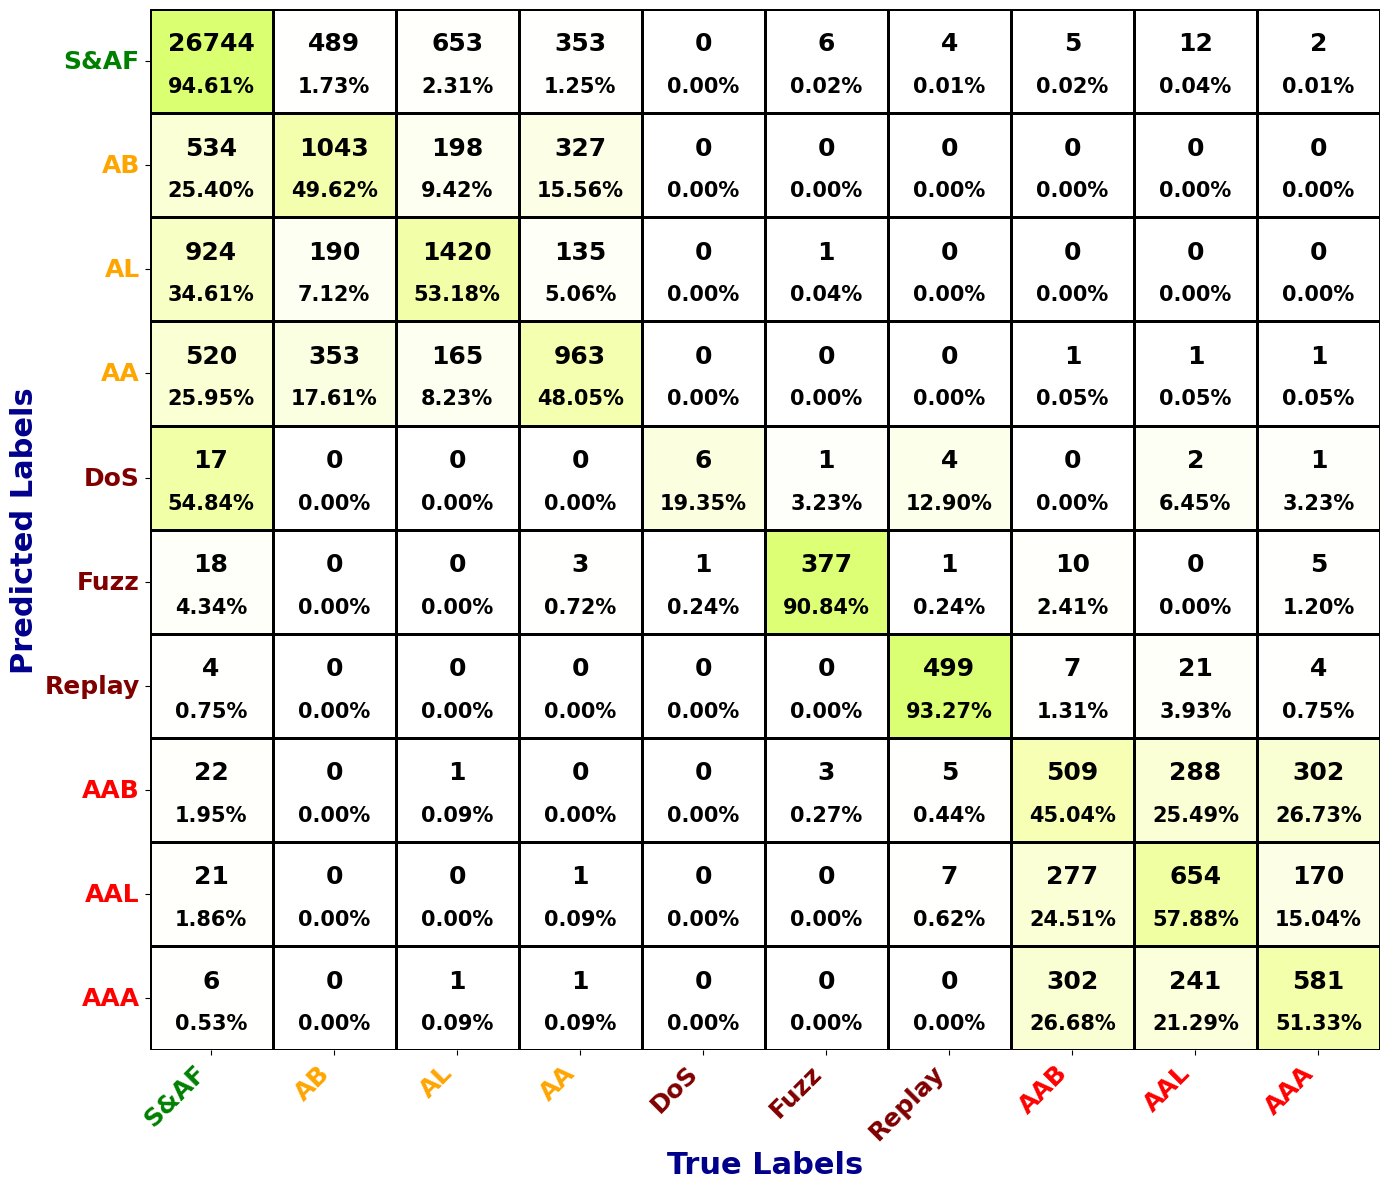

In [30]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Make sure your class order matches the integer labels 0..9 used in training
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "AAB", "AAL", "AAA"]

@torch.no_grad()
def get_prediction(model, loader, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    y_true_all = []
    y_pred_all = []

    for batch in loader:
        # If your dataset returns (X_img, X_seq, y)
        if len(batch) == 3:
            X_img, X_seq, y = batch
            X_img = X_img.to(device, non_blocking=True)
            X_seq = X_seq.to(device, non_blocking=True)
            logits = model(X_img, X_seq)
        else:
            # fallback: (X, y)
            X, y = batch
            X = X.to(device, non_blocking=True)
            logits = model(X)

        pred = logits.argmax(dim=1).detach().cpu().numpy()
        y_true = y.detach().cpu().numpy()

        y_pred_all.append(pred)
        y_true_all.append(y_true)

    y_pred_all = np.concatenate(y_pred_all)
    y_true_all = np.concatenate(y_true_all)
    return y_pred_all, y_true_all


# ---- Run evaluation ----
y_pred, y_true = get_prediction(model, test_loader)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

cf_matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(class_labels))))
plot_confusion_matrix(cf_matrix, class_labels)

In [32]:
def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

params = count_parameters(model, trainable_only=True)
print(f"Trainable params: {params:,}")
print(f"Model size (fp32): {params*4/1024/1024:.2f} MB")

Trainable params: 374,900
Model size (fp32): 1.43 MB


In [33]:
import torch
from thop import profile

device = next(model.parameters()).device

# Example inputs for LiPar
x_img = torch.randn(1, 3, 9, 9).to(device)
x_seq = torch.randn(1, 27, 9).to(device)

# IMPORTANT: give both inputs (your forward is forward(x_img, x_seq))
macs, params_thop = profile(model, inputs=(x_img, x_seq), verbose=False)

# thop returns MACs (multiply-accumulate). FLOPs are often reported as 2*MACs.
flops = 2 * macs

print(f"THOP params: {params_thop:,}")
print(f"MACs : {macs:,}")
print(f"FLOPs: {flops:,}")
print(f"FLOPs (GFLOPs): {flops/1e9:.6f}")

THOP params: 374,900.0
MACs : 2,326,048.0
FLOPs: 4,652,096.0
FLOPs (GFLOPs): 0.004652
